In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

CSV = '../outputs/hyperparameter_tuning/sweep_results.csv'
METRIC = 'lr_f1_macro'  # change to: lr_f1_macro, lr_auc_macro, protege_proj_recall_auc

df = pd.read_csv(CSV)
df = df[df['status'] == 'complete'].copy()
print(f"{len(df)} complete runs   |   metric: {METRIC}")
df[['run_name', 'projection_dim', 'weight_decay', 'lr_schedule', 'augmentation', 'vicreg', METRIC]].sort_values(METRIC, ascending=False).head(10)

42 complete runs   |   metric: lr_f1_macro


,run_name,projection_dim,weight_decay,lr_schedule,augmentation,vicreg,lr_f1_macro
6,pd128_qext_v1_wd1e-3_lrconst_20260730_1317,128,0.0010,constant,quart_ext,on,0.709623
7,pd128_qext_v1_wd1e-3_lrstep_20260730_1317,128,0.0010,step,quart_ext,on,0.707542
2,pd128_wd1e-3_lrconst_20260729_1621,128,0.0010,constant,quart_ext,off,0.695034
27,pd512_wd1e-3_lrstep_20260729_1624,512,0.0010,step,quart_ext,off,0.688360
3,pd128_wd1e-3_lrstep_20260729_1622,128,0.0010,step,quart_ext,off,0.687123
26,pd512_wd1e-3_lrconst_20260729_1624,512,0.0010,constant,quart_ext,off,0.684799
5,pd128_wd1e-4_lrstep_20260729_1621,128,0.0001,step,quart_ext,off,0.683881
20,pd32_wd1e-3_lrconst_20260729_1620,32,0.0010,constant,quart_ext,off,0.683502
4,pd128_wd1e-4_lrconst_20260729_1621,128,0.0001,constant,quart_ext,off,0.681537
30,pd512_qext_v1_wd1e-3_lrconst_20260730_1319,512,0.0010,constant,quart_ext,on,0.680168


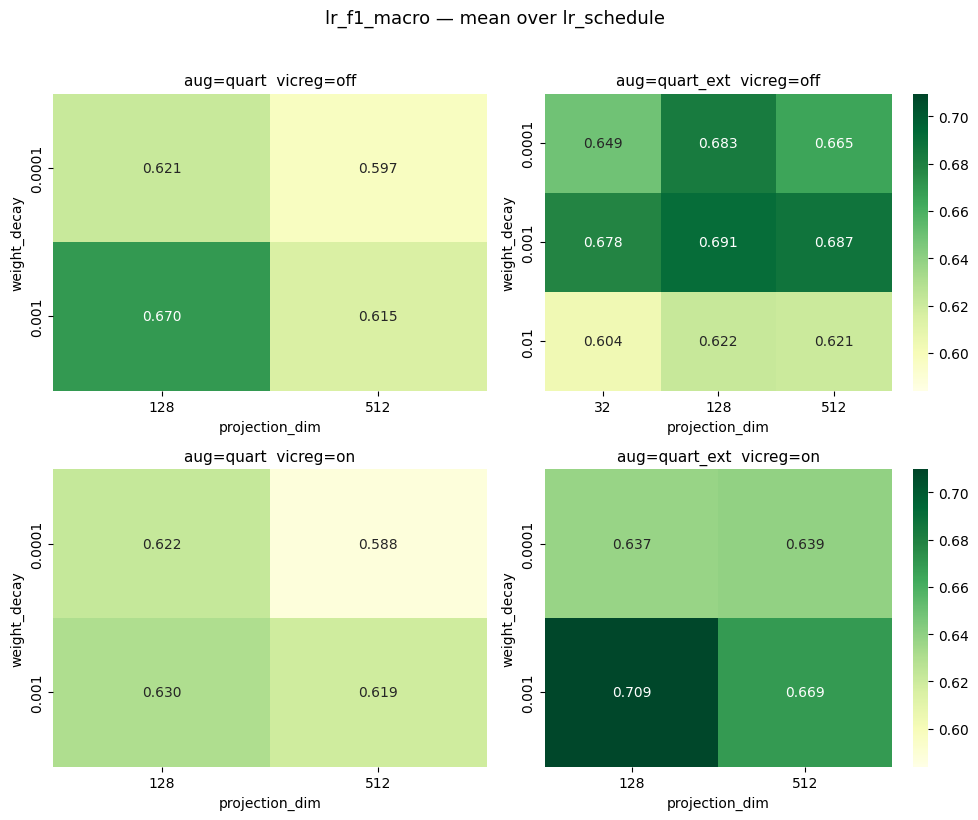

In [2]:
# Heatmap: weight_decay x projection_dim, faceted by augmentation x vicreg
augs = sorted(df['augmentation'].dropna().unique())
vics = sorted(df['vicreg'].dropna().unique())

vmin, vmax = df[METRIC].min(), df[METRIC].max()
fig, axes = plt.subplots(len(vics), len(augs), figsize=(5 * len(augs), 4 * len(vics)), squeeze=False)

for r, vic in enumerate(vics):
    for c, aug in enumerate(augs):
        ax = axes[r][c]
        sub = df[(df.augmentation == aug) & (df.vicreg == vic)]
        if sub.empty:
            ax.set_visible(False)
            continue
        pivot = sub.pivot_table(index='weight_decay', columns='projection_dim',
                                values=METRIC, aggfunc='mean')
        sns.heatmap(pivot, ax=ax, annot=True, fmt='.3f', cmap='YlGn',
                    vmin=vmin, vmax=vmax, cbar=(c == len(augs) - 1))
        ax.set_title(f'aug={aug}  vicreg={vic}', fontsize=11)

fig.suptitle(f'{METRIC} — mean over lr_schedule', y=1.02, fontsize=13)
plt.tight_layout()
plt.show()

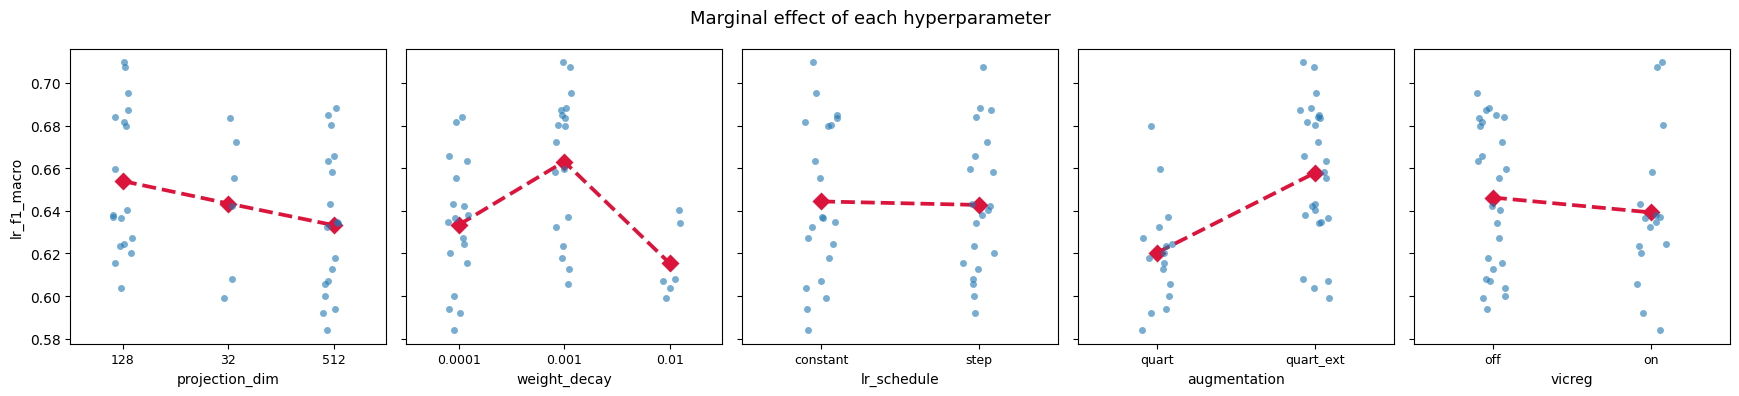

In [3]:
# Marginal effect of each axis
axes_cols = ['projection_dim', 'weight_decay', 'lr_schedule', 'augmentation', 'vicreg']
fig, axes = plt.subplots(1, len(axes_cols), figsize=(3.5 * len(axes_cols), 4), sharey=True)

for ax, col in zip(axes, axes_cols):
    order = sorted(df[col].dropna().unique(), key=str)
    sns.stripplot(data=df, x=col, y=METRIC, ax=ax, order=order,
                  jitter=True, size=5, alpha=0.6)
    sns.pointplot(data=df, x=col, y=METRIC, ax=ax, order=order,
                  estimator='mean', color='crimson', markers='D',
                  linestyles='--', errorbar=None)
    ax.set_xlabel(col, fontsize=10)
    ax.tick_params(axis='x', labelsize=9)

axes[0].set_ylabel(METRIC)
fig.suptitle('Marginal effect of each hyperparameter', fontsize=13)
plt.tight_layout()
plt.show()

In [5]:
# Full ranked table
cols = ['run_name', 'projection_dim', 'weight_decay', 'lr_schedule',
        'augmentation', 'vicreg', 'lr_f1_macro', 'lr_auc_macro', 'protege_proj_recall_auc', 
         'train_friend_loss_final',
        'train_loss_best', 'train_loss_best_epoch', 'train_loss_final']
available = [c for c in cols if c in df.columns]
df[available].sort_values(METRIC, ascending=False).style \
    .background_gradient(subset=[METRIC], cmap='YlGn') \
    .format({c: '{:.4f}' for c in available if df[c].dtype == float})

,run_name,projection_dim,weight_decay,lr_schedule,augmentation,vicreg,lr_f1_macro,lr_auc_macro,protege_proj_recall_auc,train_friend_loss_final,train_loss_best,train_loss_best_epoch,train_loss_final
6,pd128_qext_v1_wd1e-3_lrconst_20260730_1317,128,0.0010,constant,quart_ext,on,0.7096,0.9423,0.6541,3.5677,0.1167,285,0.1179
7,pd128_qext_v1_wd1e-3_lrstep_20260730_1317,128,0.0010,step,quart_ext,on,0.7075,0.9413,0.6515,3.6226,0.1025,282,0.1038
2,pd128_wd1e-3_lrconst_20260729_1621,128,0.0010,constant,quart_ext,off,0.6950,0.9430,0.6584,3.1749,0.0807,164,0.0888
27,pd512_wd1e-3_lrstep_20260729_1624,512,0.0010,step,quart_ext,off,0.6884,0.9441,0.6452,3.2262,0.0620,264,0.0644
3,pd128_wd1e-3_lrstep_20260729_1622,128,0.0010,step,quart_ext,off,0.6871,0.9415,0.6561,3.2549,0.0666,226,0.0719
26,pd512_wd1e-3_lrconst_20260729_1624,512,0.0010,constant,quart_ext,off,0.6848,0.9439,0.6383,3.3740,0.0744,227,0.0882
5,pd128_wd1e-4_lrstep_20260729_1621,128,0.0001,step,quart_ext,off,0.6839,0.9465,0.6447,3.5547,0.0639,214,0.0704
20,pd32_wd1e-3_lrconst_20260729_1620,32,0.0010,constant,quart_ext,off,0.6835,0.9408,0.6451,3.5124,0.0686,153,0.0779
4,pd128_wd1e-4_lrconst_20260729_1621,128,0.0001,constant,quart_ext,off,0.6815,0.9464,0.6457,3.5766,0.0679,153,0.0838
30,pd512_qext_v1_wd1e-3_lrconst_20260730_1319,512,0.0010,constant,quart_ext,on,0.6802,0.9346,0.6493,3.4599,0.1362,299,0.1362
